# Calcolo la TF-IDF come rappresentazione dei personaggi

Un documento -> un dizionario personaggio estratto da Propp

### Lettura file (con limite a 5 personaggi)

In [1]:
def read_booknlp(path_book):
    with open(path_book, "r", encoding="utf-8") as file:
        lines = file.readlines()
        dicts = [eval(line.strip()) for line in lines if line.strip()]
    return dicts[:5]   # mantengo i primi 5 personaggi

### Estrazione parole da un personaggio

In [2]:
def extract_words_from_character(char_dict):
    words = []
    
    for key in ['agent', 'patient', 'mod', 'poss']:
        if key in char_dict:
            words.extend([item['w'] for item in char_dict[key]])
    
    return words

### Costruzione dei documenti dei personaggi

In [3]:
documents = []
metadata = []

In [ ]:
import glob
import os

book_files = glob.glob(os.path.join("Corpus_propp", "*.book"))

for filepath in book_files:
    filename = os.path.basename(filepath)
    book_data = read_booknlp(filepath)  # già limitato a [:5]
    
    for idx, char_dict in enumerate(book_data):
        
        # --------- TESTO DEL PERSONAGGIO ---------
        words = []
        for key_field in ['agent', 'patient', 'mod', 'poss']:
            if key_field in char_dict:
                words.extend([item['w'] for item in char_dict[key_field]])
        
        documents.append(" ".join(words))  # TF-IDF vuole stringhe
        
        # --------- GENDER ---------
        if char_dict['gender'].get("argmax") == "Female":
            gender_label = 1
        else:
            gender_label = 0
        
        # --------- NOME PERSONAGGIO ---------
        if (
            "mentions" in char_dict and
            char_dict["mentions"].get("proper") and
            len(char_dict["mentions"]["proper"]) > 0
        ):
            char_name = char_dict["mentions"]["proper"][0]["n"].lower()
        else:
            char_name = f"char{idx+1}"
        
        metadata.append({
            "filename": filename,
            "character_name": char_name,
            "gender": gender_label
        })

## Salvataggio delle parole per ogni personaggio in un csv

In [ ]:
import pandas as pd

rows = []

for i in range(len(documents)):
    filename = metadata[i]["filename"]
    print(filename)
    character_name = metadata[i]["character_name"]
    row = {
        "title" : f"{filename} --- {character_name}",
        "author_gender" : "",
        "Gender": metadata[i]["gender"],
        "type" : "",
        "text": documents[i]
    }
    rows.append(row)

df = pd.DataFrame(rows)

In [25]:
print(df.head())
print(df.shape)   # dovrebbe essere (600, 4)

                                               title author_gender  Gender  \
0  1883_Halt-Marie-Robert_Histoire-d-un-petit-hom...                     0   
1  1883_Halt-Marie-Robert_Histoire-d-un-petit-hom...                     0   
2  1883_Halt-Marie-Robert_Histoire-d-un-petit-hom...                     1   
3  1883_Halt-Marie-Robert_Histoire-d-un-petit-hom...                     0   
4  1883_Halt-Marie-Robert_Histoire-d-un-petit-hom...                     1   

  type                                               text  
0       remplir humer répondre avoir ajouter souffrir ...  
1       manger entrer penser trouver passer dire prête...  
2       venir ébrouer obéir acheter rire garder ajoute...  
3       devenir connaître tirer ouvrir donner reprendr...  
4       arriver répondre entendre répondre écouter saî...  
(1230, 5)


In [26]:
df.to_csv("tf-idf_personnages.csv", index=False, encoding="utf-8")

## Ricaricare il file per le analisi successive

Avere cura di passare le annotazioni con lo script (cartella Utilities)

In [ ]:
import pandas as pd

df = pd.read_csv("tf-idf_personnages_ann.csv")

In [2]:
# creation d'un nouveau dataframe ne contenant que les types 0 (adult) et 1 (enfant)
df = df[df["type"].isin([0,1])]

In [3]:
# suppression de la colonne des titres et des celles du genre
df.drop(columns=["title", "type","author_gender"], axis=1, inplace=True)

In [9]:
df.head(5)

,Gender,text
0,0,remplir humer répondre avoir ajouter souffrir ...
1,0,manger entrer penser trouver passer dire prête...
2,1,venir ébrouer obéir acheter rire garder ajoute...
3,0,devenir connaître tirer ouvrir donner reprendr...
4,1,arriver répondre entendre répondre écouter saî...


In [4]:
documents = df["text"].tolist()
y = df["Gender"].tolist()

## Creazione matrice TF-IDF

Dato che lavoro su personaggi, potrebbe essere utile:

min_df=2 o 3
max_df=0.8

Perché:

- elimina parole che compaiono in un solo personaggio
- elimina parole troppo comuni (tipo "faire", "dire", "être")

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=2)
X_tfidf = vectorizer.fit_transform(documents)

## Addestramento SVM sul genere

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Inizializza il modello SVM
# Usiamo un kernel lineare, solitamente il più efficace per il testo
svm_model = SVC(kernel='linear', C=1.0)

# 2. Configura il metodo di splitting (StratifiedKFold è ideale per mantenere le proporzioni delle classi)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Esegui la Cross Validation
# Calcoliamo l'accuratezza su 5 "fold" diversi
scores = cross_val_score(svm_model, X_tfidf, y, cv=skf, scoring='accuracy')

# 4. Risultati
print(f"Accuratezza media: {scores.mean():.4f}")
print(f"Deviazione standard: {scores.std():.4f}")
print(f"Punteggi per ogni fold: {scores}")

Accuratezza media: 0.8580
Deviazione standard: 0.0382
Punteggi per ogni fold: [0.8        0.85454545 0.83636364 0.9        0.89908257]


In [18]:
from sklearn.model_selection import cross_validate

scoring = ['precision', 'recall', 'f1']

results = cross_validate(svm_model, X_tfidf, y, cv=skf, scoring=scoring)

print(f"Precision media: {results['test_precision'].mean():.4f}")
print(f"Recall medio: {results['test_recall'].mean():.4f}")
print(f"F1 medio: {results['test_f1'].mean():.4f}")

Precision media: 0.8902
Recall medio: 0.7837
F1 medio: 0.8302


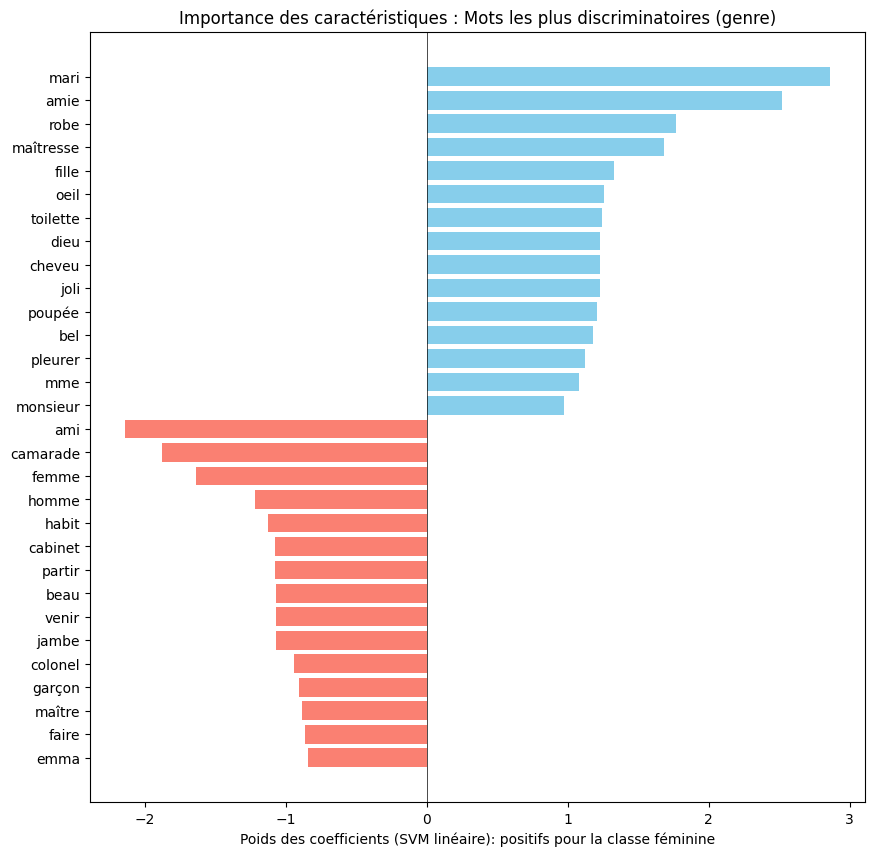

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 2. Addestramento Finale ---
svm_model.fit(X_tfidf, y)

# --- 3. Estrazione Feature Importance ---
# Otteniamo i pesi (coefficienti) e i nomi delle parole
coefs = svm_model.coef_.toarray()[0]
feature_names = np.array(vectorizer.get_feature_names_out())

# Creiamo un DataFrame per manipolare i dati facilmente
importance_df = pd.DataFrame({'word': feature_names, 'weight': coefs})

# --- 4. Selezione delle parole chiave per ogni classe ---
# Supponiamo: Classe 0 (es. Maschio) e Classe 1 (es. Femmina)
# I pesi negativi spingono verso la Classe 0, quelli positivi verso la Classe 1
top_class_1 = importance_df.sort_values(by='weight', ascending=False).head(15)
top_class_0 = importance_df.sort_values(by='weight', ascending=True).head(15)

# Uniamo per il grafico
top_features = pd.concat([top_class_1, top_class_0])

# --- 5. Visualizzazione ---
plt.figure(figsize=(10, 10))
colors = ['skyblue' if w > 0 else 'salmon' for w in top_features['weight']]
plt.barh(top_features['word'], top_features['weight'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel("Poids des coefficients (SVM linéaire): positifs pour la classe féminine")
plt.title("Importance des caractéristiques : Mots les plus discriminatoires (genre)")
plt.gca().invert_yaxis()
plt.show()

## Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Inizializza il modello Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Configura lo splitting
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Cross-validation
scores = cross_val_score(rf_model, X_tfidf, y, cv=skf, scoring='accuracy', n_jobs=-1)

# 4. Risultati
print(f"Accuratezza media: {scores.mean():.4f}")
print(f"Deviazione standard: {scores.std():.4f}")
print(f"Punteggi per ogni fold: {scores}")

Accuratezza media: 0.8616
Deviazione standard: 0.0320
Punteggi per ogni fold: [0.85454545 0.80909091 0.85454545 0.89090909 0.89908257]


In [7]:
from sklearn.model_selection import cross_validate

scoring = ['precision', 'recall', 'f1']

results = cross_validate(rf_model, X_tfidf, y, cv=skf, scoring=scoring)

print(f"Precision media: {results['test_precision'].mean():.4f}")
print(f"Recall medio: {results['test_recall'].mean():.4f}")
print(f"F1 medio: {results['test_f1'].mean():.4f}")

Precision media: 0.9384
Recall medio: 0.7388
F1 medio: 0.8255
